In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font',size=18)

In [2]:
from pynitride.devices import gan_pfet
from pynitride.paramdb import nm,cm, k
from pynitride.solvers import PoissonSolver, Equilibrium, SelfConsistentLoop
from pynitride.carriers import Semiclassical, Schrodinger, MultibandKP

# Semiclassical

In [3]:
m,[scm,clm]=gan_pfet(8*nm,200*nm,Ndef=5e16/cm**3)

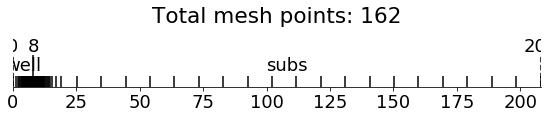

In [4]:
m.plot_mesh()

In [5]:
Equilibrium(m)
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Semiclassical(m)])

In [6]:
scl.ramp_epsfactor(max_iter=20)

Starting eps factor ramp from 10000 to 1
  Eps factor: 1.00e+04
  Starting SC loop
    iter:   0  err: 4.52e-16  activ: 1
    Loop finished in  1 iterations with err=4.51723e-16
  Eps factor: 6.31e+03
  Starting SC loop
    iter:   0  err: 4.04e-04  activ: 1
    iter:   1  err: 1.76e-16  activ: 1
    Loop finished in  2 iterations with err=1.76196e-16
  Eps factor: 2.51e+03
  Starting SC loop
    iter:   0  err: 1.66e-03  activ: 1
    iter:   1  err: 5.62e-16  activ: 1
    Loop finished in  2 iterations with err=5.61613e-16
  Eps factor: 7.94e+02
  Starting SC loop
    iter:   0  err: 5.95e-03  activ: 1
    iter:   1  err: 1.42e-15  activ: 1
    Loop finished in  2 iterations with err=1.42058e-15
  Eps factor: 2.51e+02
  Starting SC loop
    iter:   0  err: 1.88e-02  activ: 1
    iter:   1  err: 7.26e-16  activ: 1
    Loop finished in  2 iterations with err=7.2581e-16
  Eps factor: 7.94e+01
  Starting SC loop
    iter:   0  err: 5.95e-02  activ: 1
    iter:   1  err: 8.91e-15  activ: 1

In [7]:
m['E0-Ev']

Function([ 1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1.68024089,  1.68024089,  1.68024089,  1.68024089,
           1.68024089,  1

(0, 20)

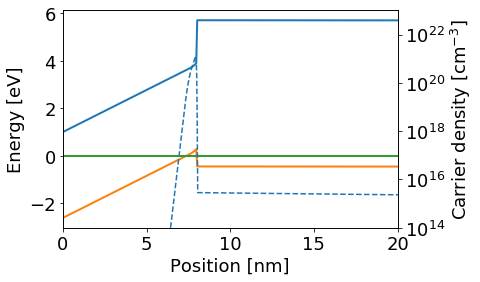

In [8]:
plt.figure()
plt.plot(m.zp,m.Ec,linewidth=2)
plt.plot(m.zp,m.Ev,linewidth=2)
plt.plot(m.zp,m.EF,linewidth=2)
plt.xlabel("Position [nm]")
plt.ylabel("Energy [eV]")

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylabel("Carrier density [cm$^{-3}$]")
plt.ylim(1e14,1e23)

plt.xlim(0,20)

In [9]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(2.9852556762531393)

In [10]:
m.P/1.602e-19

Function([  3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401e+17,   3.49240401e+17,
            3.49240401e+17,   3.49240401

# Schrodinger

In [23]:
m,[scm,clm]=gan_pfet(8*nm,200*nm,Ndef=5e16/cm**3,)

In [24]:
Equilibrium(m)

In [25]:
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Schrodinger(scm),Semiclassical(clm)])

In [26]:
scl.ramp_epsfactor(max_iter=20,dlefmin=.025)

Starting eps factor ramp from 10000 to 1
  Eps factor: 1.00e+04
  Starting SC loop
    iter:   0  err: 4.52e-16  activ: 1
    Loop finished in  1 iterations with err=4.51723e-16
  Eps factor: 6.31e+03
  Starting SC loop
    iter:   0  err: 4.04e-04  activ: 1
    iter:   1  err: 1.76e-16  activ: 1
    Loop finished in  2 iterations with err=1.76196e-16
  Eps factor: 2.51e+03
  Starting SC loop
    iter:   0  err: 1.66e-03  activ: 1
    iter:   1  err: 5.62e-16  activ: 1
    Loop finished in  2 iterations with err=5.61614e-16
  Eps factor: 7.94e+02
  Starting SC loop
    iter:   0  err: 5.95e-03  activ: 1
    iter:   1  err: 1.42e-15  activ: 1
    Loop finished in  2 iterations with err=1.42059e-15
  Eps factor: 2.51e+02
  Starting SC loop
    iter:   0  err: 1.88e-02  activ: 1
    iter:   1  err: 7.26e-16  activ: 1
    Loop finished in  2 iterations with err=7.25814e-16
  Eps factor: 7.94e+01
  Starting SC loop
    iter:   0  err: 5.95e-02  activ: 1
    iter:   1  err: 8.91e-15  activ: 

(0, 20)

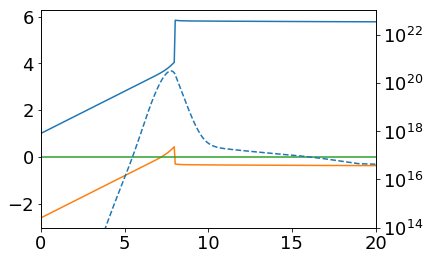

In [27]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,20)

NameError: name 'sw' is not defined

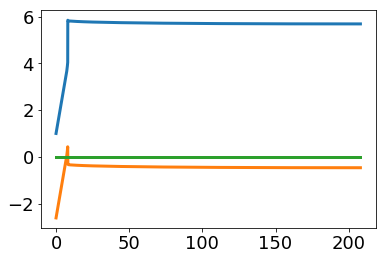

In [16]:
plt.figure()
plt.plot(m.zp,m.Ec,linewidth=3)
plt.plot(m.zp,m.Ev,linewidth=3)
plt.plot(m.zp,m.EF,linewidth=3)
plt.plot(scm.zp,sw[:,:1,0])
plt.plot(scm.zp,sw[:,:1,1])
plt.plot(scm.zp,sw[:,:1,2])
plt.plot(scm.zp,scm.hen.T[:,0,:],'--')
plt.ylim(-.5,.75)
plt.ylabel("Energy [eV]")
plt.xlabel("Depth [nm]")

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'-')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('lin')
#plt.ylim(1e14,1e23)
plt.ylabel("Carrier density [cm$^{-3}$]")
plt.xlim(5,11.9)

In [14]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(2.9264562392388207)

# KPSolver

In [17]:
m,[scm,clm]=gan_pfet(8*nm,200*nm,Ndef=5e16/cm**3,)

In [18]:
Equilibrium(m)

In [19]:
m.ztrans

-1

In [20]:
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[MultibandKP(scm),Semiclassical(scm,'electron'),Semiclassical(clm)])

Assembling k.p matrices ...
Done assembly.


In [21]:
%%timeit -n 1 -r 1
scl.ramp_epsfactor(start=1e1,max_iter=30)

Starting eps factor ramp from 10 to 1
  Eps factor: 1.00e+01
  Starting SC loop
    iter:   0  err: 2.47e-14  activ: 1
    Loop finished in  1 iterations with err=2.47371e-14
  Eps factor: 6.31e+00
  Starting SC loop
    iter:   0  err: 4.04e-01  activ: 1
    iter:   1  err: 1.77e-13  activ: 1
    Loop finished in  2 iterations with err=1.77399e-13
  Eps factor: 2.51e+00
  Starting SC loop
    iter:   0  err: 1.66e+00  activ: 1
    iter:   1  err: 1.04e-02  activ: 1
    iter:   2  err: 7.92e-04  activ: 1
    iter:   3  err: 3.71e-06  activ: 1
    iter:   4  err: 1.37e-09  activ: 1
    Loop finished in  5 iterations with err=1.37373e-09
  Eps factor: 1.00e+00
  Starting SC loop
    iter:   0  err: 2.08e+00  activ: 1
    iter:   1  err: 3.27e+01  activ: 1
    Retrying with Poisson activation=0.5
           iter:   1  err: 6.54e+00
    Retrying with Poisson activation=0.25
           iter:   1  err: 5.43e+00
    Retrying with Poisson activation=0.125
           iter:   1  err: 4.96e+00
  

Exception: Eps factor step size too small

(0, 20)

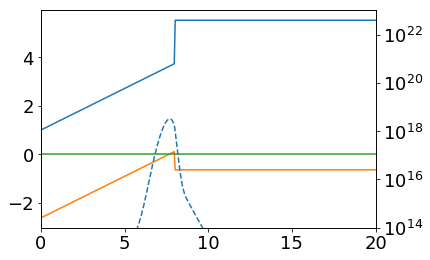

In [22]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.pderiv*k*m.T.tpf()/(1/cm**3),'.--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,20)

In [ ]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.plot

#plt.twinx()
#plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('log')
#plt.ylim(1e14,1e23)
#plt.xlim(0,20)

In [24]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(3.414648592697289)

# Schro then KPSolver

In [39]:
from pynitride.visual import log
import numpy as np
log._depth=0
log._showlevel=np.inf

In [40]:
m,[scm,clm]=gan_pfet(8*nm,200*nm,Ndef=5e16/cm**3,)

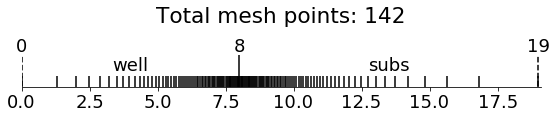

In [41]:
scm.plot_mesh()

In [42]:
Equilibrium(m)

In [64]:
#%%timeit -n 1 -r 1
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Schrodinger(scm,'hole'),Semiclassical(scm,'electron'),Semiclassical(clm)])
scl.ramp_epsfactor(start=1e3,max_iter=20,dlefmin=.025)
#mbkp=MultibandKP(scm)
#for cs in [mbkp,Schrodinger(scm,'electron'),Semiclassical(clm)]:
#    cs.solve()
#print(scl._fs[0].isolve())
#for cs in [mbkp,Schrodinger(scm,'electron'),Semiclassical(clm)]:
#    cs.solve()
#print(scl._fs[0].isolve())
psm=PoissonSolver(m)
psm.solve()
mbkp=MultibandKP(scm)
for H in mbkp._H:
    H[:6,:6]*=2
    H[-6:,-6:]*=2
scl=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[mbkp,Semiclassical(scm,'electron'),Semiclassical(clm)])
scl.loop(tol=1e-8)

Starting eps factor ramp from 1000 to 1
  Eps factor: 1.00e+03
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   0  err: 4.10e-03  activ: 1
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   1  err: 9.40e-16  activ: 1
    Loop finished in  2 iterations with err=9.40246e-16
  Eps factor: 6.31e+02
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   0  err: 4.04e-03  activ: 1
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   1  err: 6.13e-16  activ: 1
    Loop finished in  2 iterations with err=6.13394e-16
  Eps factor: 2.51e+02
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   0  err: 1.66e-02  

    Poisson iSolve
           iter:   3  err: 1.38e-01
    Retrying with Poisson activation=0.0625
  Failure: Couldn't reduce error in SC loop
  Restoring at 2.51e+00
  Using averaged effective mass to parabolically populate schrodinger bands
  Eps factor: 2.18e+00
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   0  err: 3.92e-01  activ: 1
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   1  err: 1.47e-01  activ: 1
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   2  err: 1.50e-01  activ: 1
    Retrying with Poisson activation=0.5
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
           iter:   2  err: 1.53e-01
    Retrying with Poisson activation=0.25
    Using averaged effective mass to parabolically populate schrodinger ba

  not blending
  Poisson iSolve
  iter:   8  err: 2.25e-03  activ: 0.895795
  MBKP Solve
  not blending
  Poisson iSolve
  iter:   9  err: 2.91e-04  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  10  err: 2.18e-05  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  11  err: 6.23e-06  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  12  err: 1.82e-06  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  13  err: 5.36e-07  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  14  err: 1.58e-07  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  15  err: 4.69e-08  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  16  err: 1.39e-08  activ: 1
  MBKP Solve
  not blending
  Poisson iSolve
  iter:  17  err: 4.13e-09  activ: 1
  Loop finished in 18 iterations with err=4.12538e-09


(0, 20)

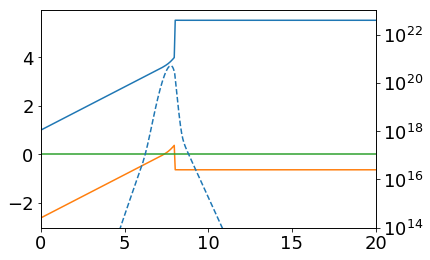

In [65]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.pderiv*k*m.T.tpf()/(1/cm**3),'.--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,20)

(-1.5, 1)

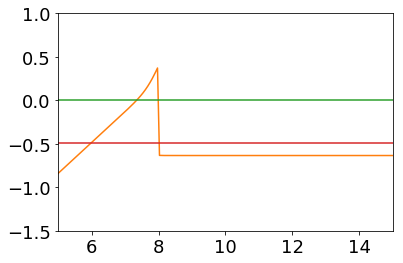

In [82]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.plot(scm.zp,scm.kpen[14,12].T)

#plt.twinx()
#plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('log')
#plt.ylim(1e14,1e23)
plt.xlim(5,15)
plt.ylim(-1.5,1)

In [76]:
mbkp.solve()

MBKP Solve
not blending


In [77]:
np.max(np.abs(mbkp._H[10][:12,:12].todense()-mbkp._H[10][:12,:12].todense().H))

0.0

(-0.8, 0.1)

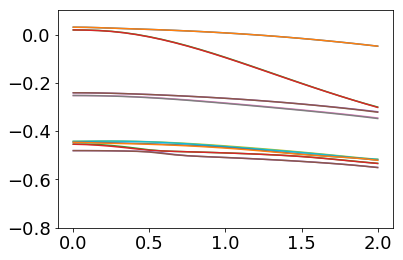

In [78]:
plt.figure()
plt.plot(mbkp._kt,scm.kpen[:,0,0],)
plt.plot(mbkp._kt,scm.kpen[:,1,0],)
plt.plot(mbkp._kt,scm.kpen[:,2,0],)
plt.plot(mbkp._kt,scm.kpen[:,3,0],)
plt.plot(mbkp._kt,scm.kpen[:,4,0],)
plt.plot(mbkp._kt,scm.kpen[:,5,0],)
plt.plot(mbkp._kt,scm.kpen[:,6,0],)
plt.plot(mbkp._kt,scm.kpen[:,7,0],)
plt.plot(mbkp._kt,scm.kpen[:,8,0],)
plt.plot(mbkp._kt,scm.kpen[:,9,0],)
plt.plot(mbkp._kt,scm.kpen[:,10,0],)
plt.plot(mbkp._kt,scm.kpen[:,11,0],)
plt.plot(mbkp._kt,scm.kpen[:,12,0],)
plt.plot(mbkp._kt,scm.kpen[:,13,0],)
plt.plot(mbkp._kt,scm.kpen[:,14,0],)
plt.plot(mbkp._kt,scm.kpen[:,15,0],)

plt.ylim(-.8,.1)

-0.49388306460524517

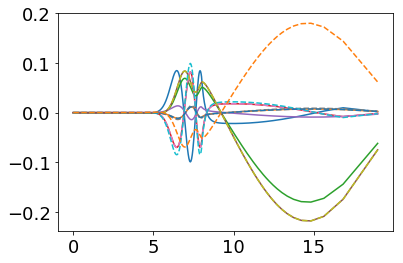

In [79]:
plt.figure()
kti=14
e=12
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,0,:])) #big
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,1,:])) #big
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,2,:])) #nothing
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,3,:])) #smaller
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,4,:])) #smaller
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,5,:])) #nothing
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,0,:]),'--') #big
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,1,:]),'--') #big
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,2,:]),'--') #nothing
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,3,:]),'--') #smaller
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,4,:]),'--') #smaller
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,5,:]),'--') #nothing
scm.kpen[kti,e,100]

In [15]:
from scipy.linalg import eigvalsh

In [16]:
Cmats=m._matsys.kp_Cmats(m,mbkp._kt,0*mbkp._kt)

In [17]:
def E(kz,ikt):
    H=Cmats[ikt][0][:,:,0]+Cmats[ikt][1][:,:,0]*kz+kz*Cmats[ikt][2][:,:,0]+kz*Cmats[ikt][3][:,:,0]*kz
    return eigvalsh(H)

In [23]:
kz=np.linspace(0,2,25)
Ez=[E(kzi,0) for kzi in kz]
Ex=[E(0,ikt) for ikt in range(len(mbkp._kt))]
Exz=[E(kzi,ikt) for kzi,ikt in zip(kz,range(len(mbkp._kt)))]
Exaz=[E(kz[19],ikt) for ikt in range(len(mbkp._kt))]

(-0.2, 0.1)

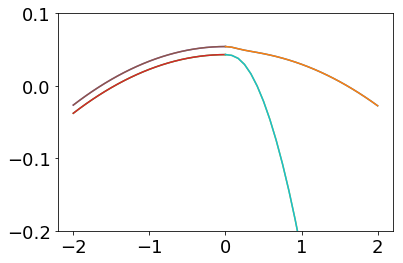

In [24]:
plt.plot(-kz,Ez)
plt.plot(mbkp._kt,Ex)
plt.ylim(-.2,.1)

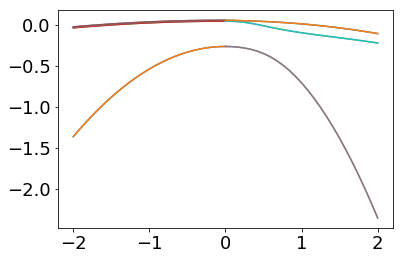

In [25]:
plt.plot(-kz,Ez)
plt.plot(kz,Exz)

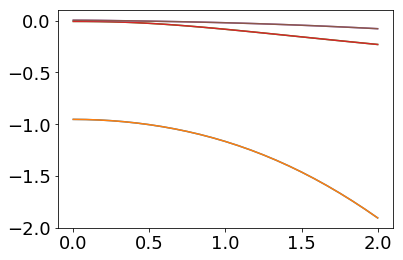

In [30]:
#plt.plot(-kz,Ez)
plt.plot(kz,Exaz)
#plt.ylim(-.1,0)

In [22]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(4.017983753740012)